In [1]:
%load_ext autoreload
%autoreload 2

# Spline model calibration

This notebook shows how to calibrate a B-spline camera model and analyze the result.

If OpenCV models are not capable of modeling your lens with adequate precision, lensboy offers much more flexible and powerful models that use B-splines to model lens distortion.

In [2]:
import lensboy as lb
import lensboy.analysis as lba
import cv2
import imageio.v3 as iio
import mediapy
from pathlib import Path

First, load the images, and look at an example image.

""

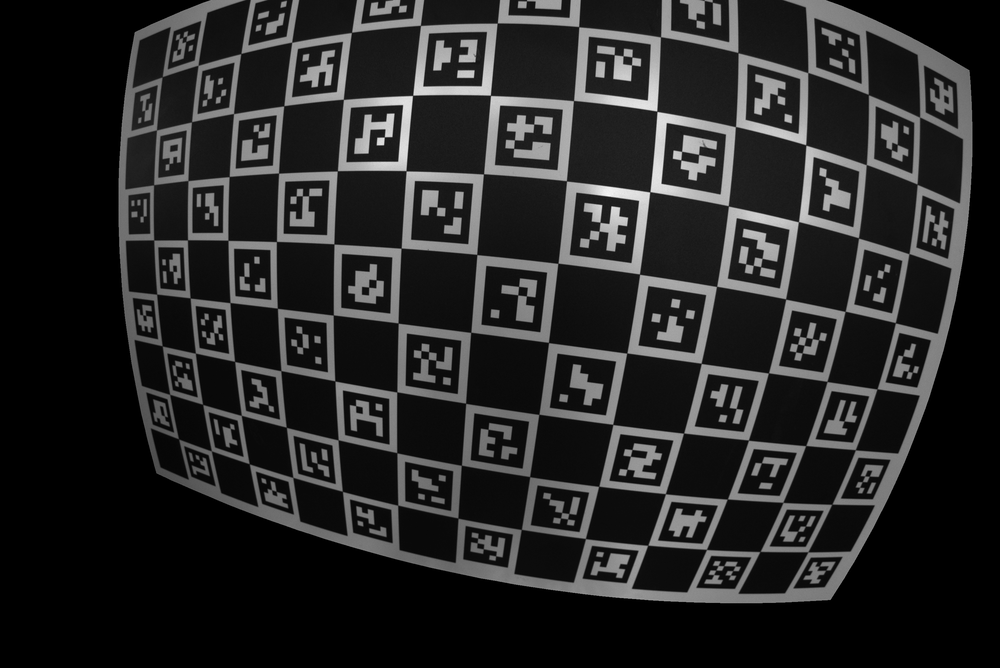

In [3]:
img_directory = Path("../data/images/wide_angle_charuco_private")
img_paths = sorted(img_directory.glob("*.png"))
imgs = [iio.imread(pth) for pth in img_paths]

# if you're running the notebook yourself, you can use this for synthetic images
# from lensboy.demo import make_synthetic_images
# imgs = make_synthetic_images()

mediapy.show_image(imgs[0], width=1000)

Extract charuco detections from the images.

In [4]:
board = cv2.aruco.CharucoBoard(
    (14, 9), 40, 30, cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
)
target_points, frames, img_indices = lb.extract_frames_from_charuco(board, imgs)
used_imgs = [imgs[i] for i in img_indices]
img_height, img_width = used_imgs[0].shape[:2]

Detecting charuco: 101/101 (100.0%)
Detected charuco in 101/101 images


Let's see how well our data covers the image space:

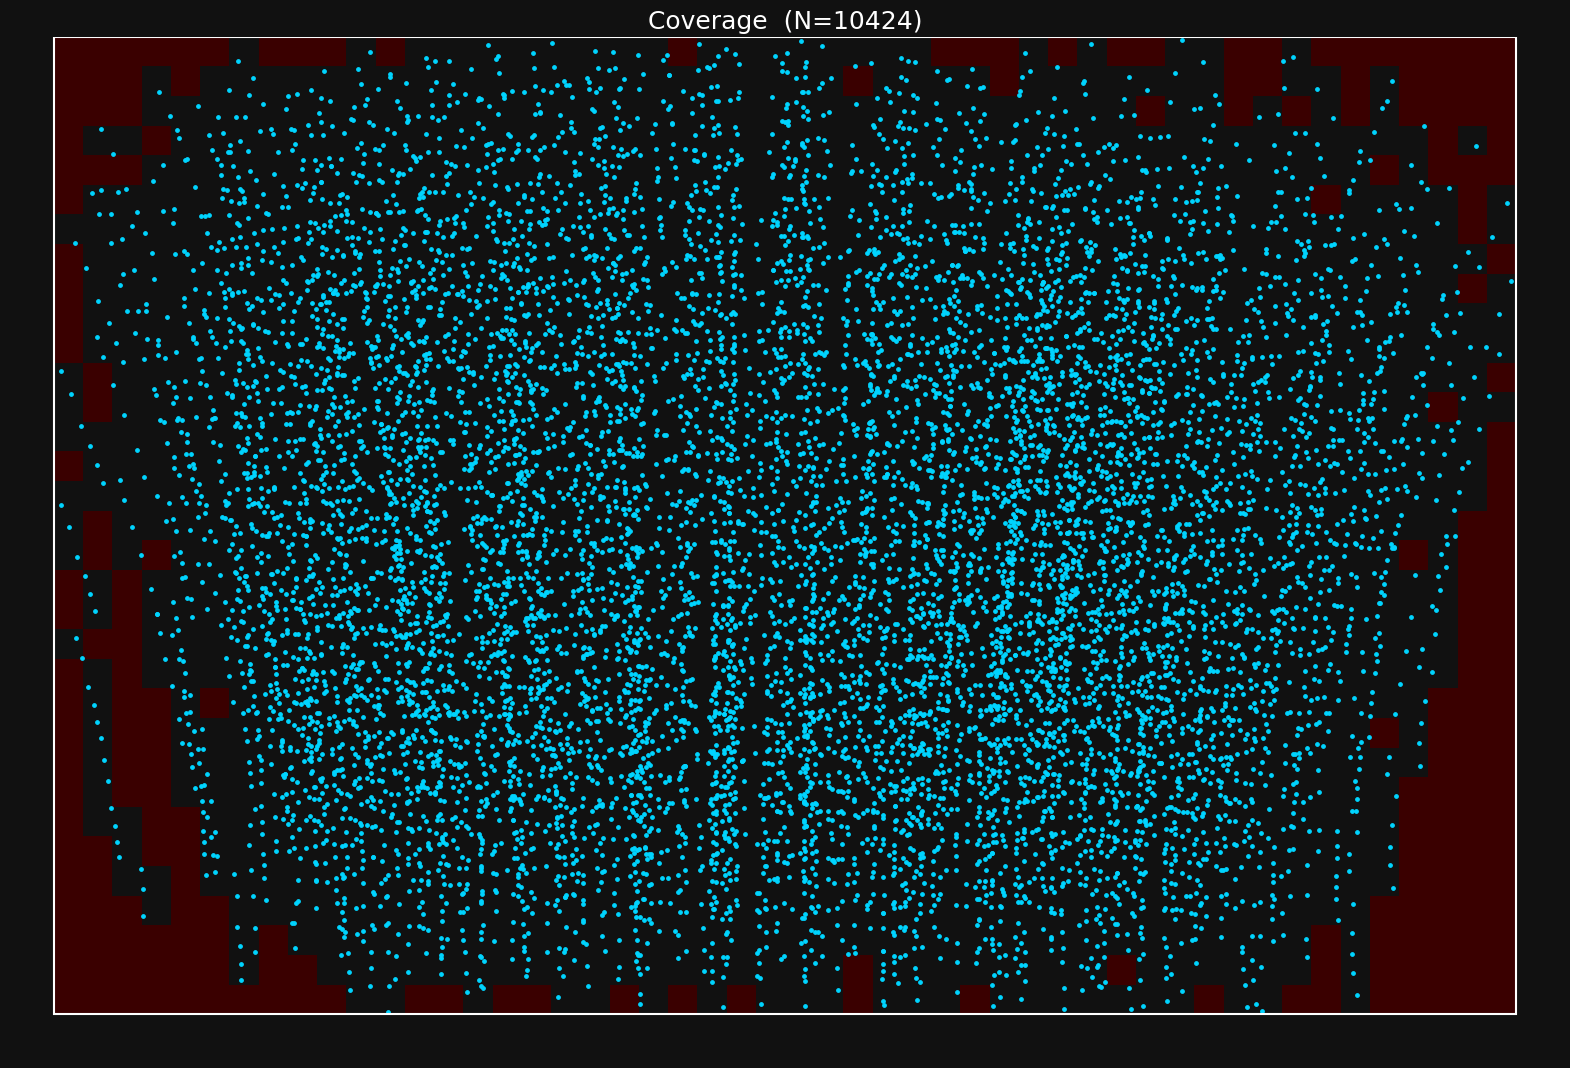

In [5]:
lba.plot_detection_coverage(frames, image_width=img_width, image_height=img_height)

Pretty good, especially for such a wide-angle camera.

# Calibrate

The spline model uses a grid of B-spline knots to model distortion. This takes longer to optimize than OpenCV models because of the increased number of parameters.

In [6]:
config = lb.PinholeSplinedConfig(
    img_height,
    img_width,
    num_knots_x=30,
    num_knots_y=20,
)
result = lb.calibrate_camera(target_points, frames, camera_model_config=config)

Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (143.6° x 127.8°)
PnP solved 101/101 frames
Spline pass 1: 2.0s (mean reproj=0.128px, worst=4.967px)
Outlier filtering: 119/10424 (1.1%) — re-optimizing...
Spline pass 2: 1.3s (mean reproj=0.114px, worst=0.574px)
Outlier filtering: 158/10424 (1.5%) — re-optimizing...
Spline pass 3: 0.7s (mean reproj=0.112px, worst=0.615px)
Target warp max deflection: 0.4766 (target units)


We can see a few things from the logs:
* Outlier filtering was performed. A low percentage is good - I would start to worry if it went over a few percent.
* The optimizer estimated some target warp. This is useful, as flat boards like these are almost never completely flat.

# Analyze result

Let's check the geometry that the solver ended up with:

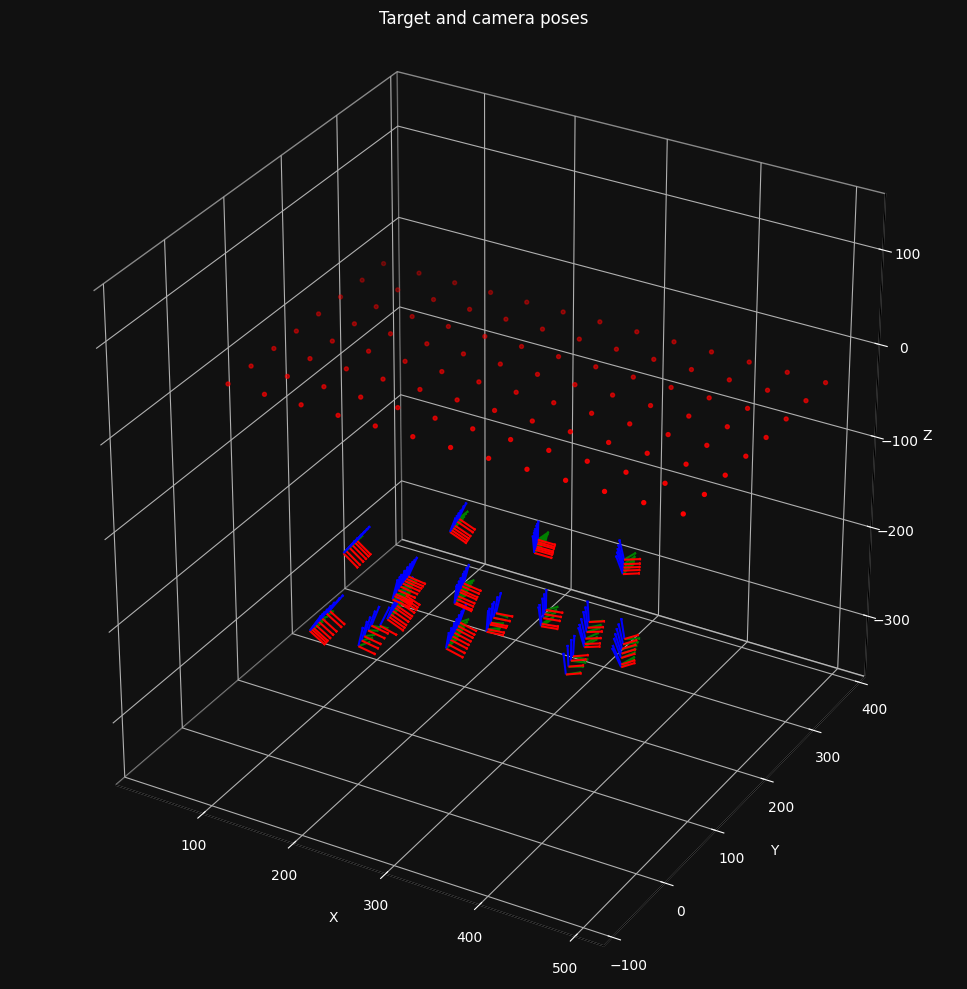

In [7]:
result.plot_target_and_poses()

Looks about right. Let's sanity check that the reprojected target points look good in an image:

""

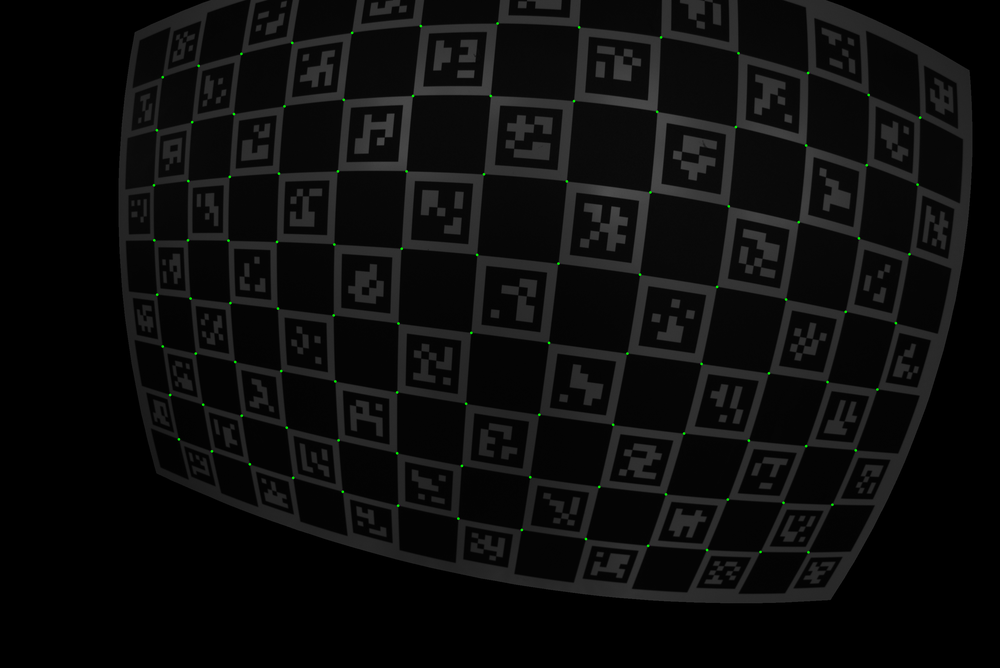

In [8]:
diagnostic = result.frame_diagnostics[0]
assert diagnostic is not None
projected_drawn = lba.draw_points(
    diagnostic.projected_points, image=used_imgs[0]
)
mediapy.show_image(projected_drawn, width=1000)

Looks good. Now let's visualize the lens distortion that the solve ended up with. Since the spline is such a powerful model, it tends to behave unpredictably on the edges where there is no data.

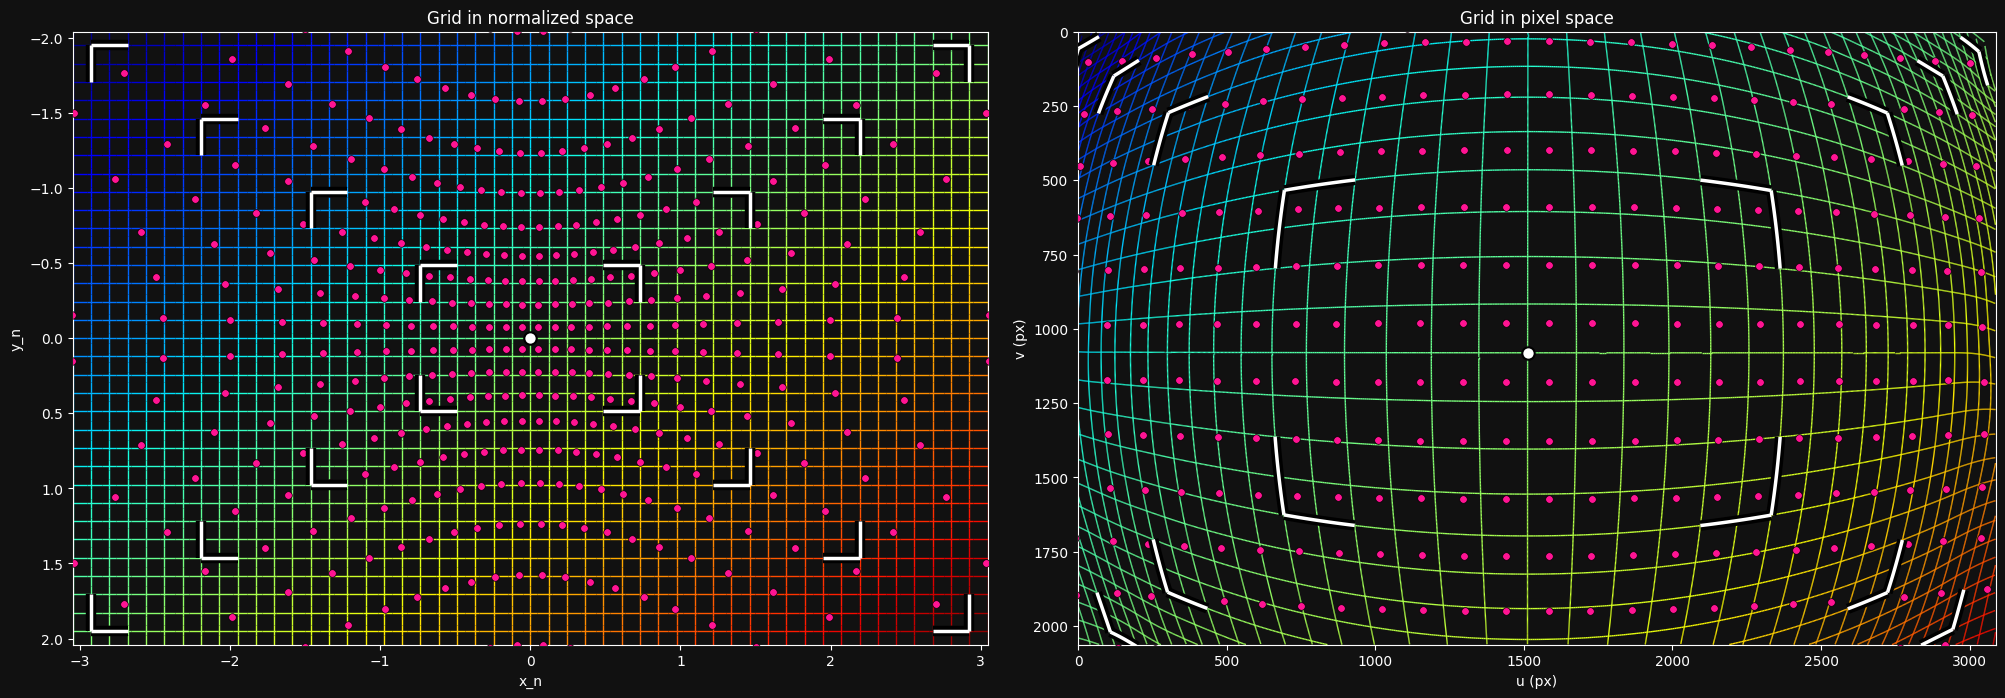

In [9]:
result.plot_distortion_grid(
    show_spline_knots=True
)

Let's now plot the residuals of the solve. We're looking for a tight, roughly gaussian spread, and roughly isotropic 2D residuals.

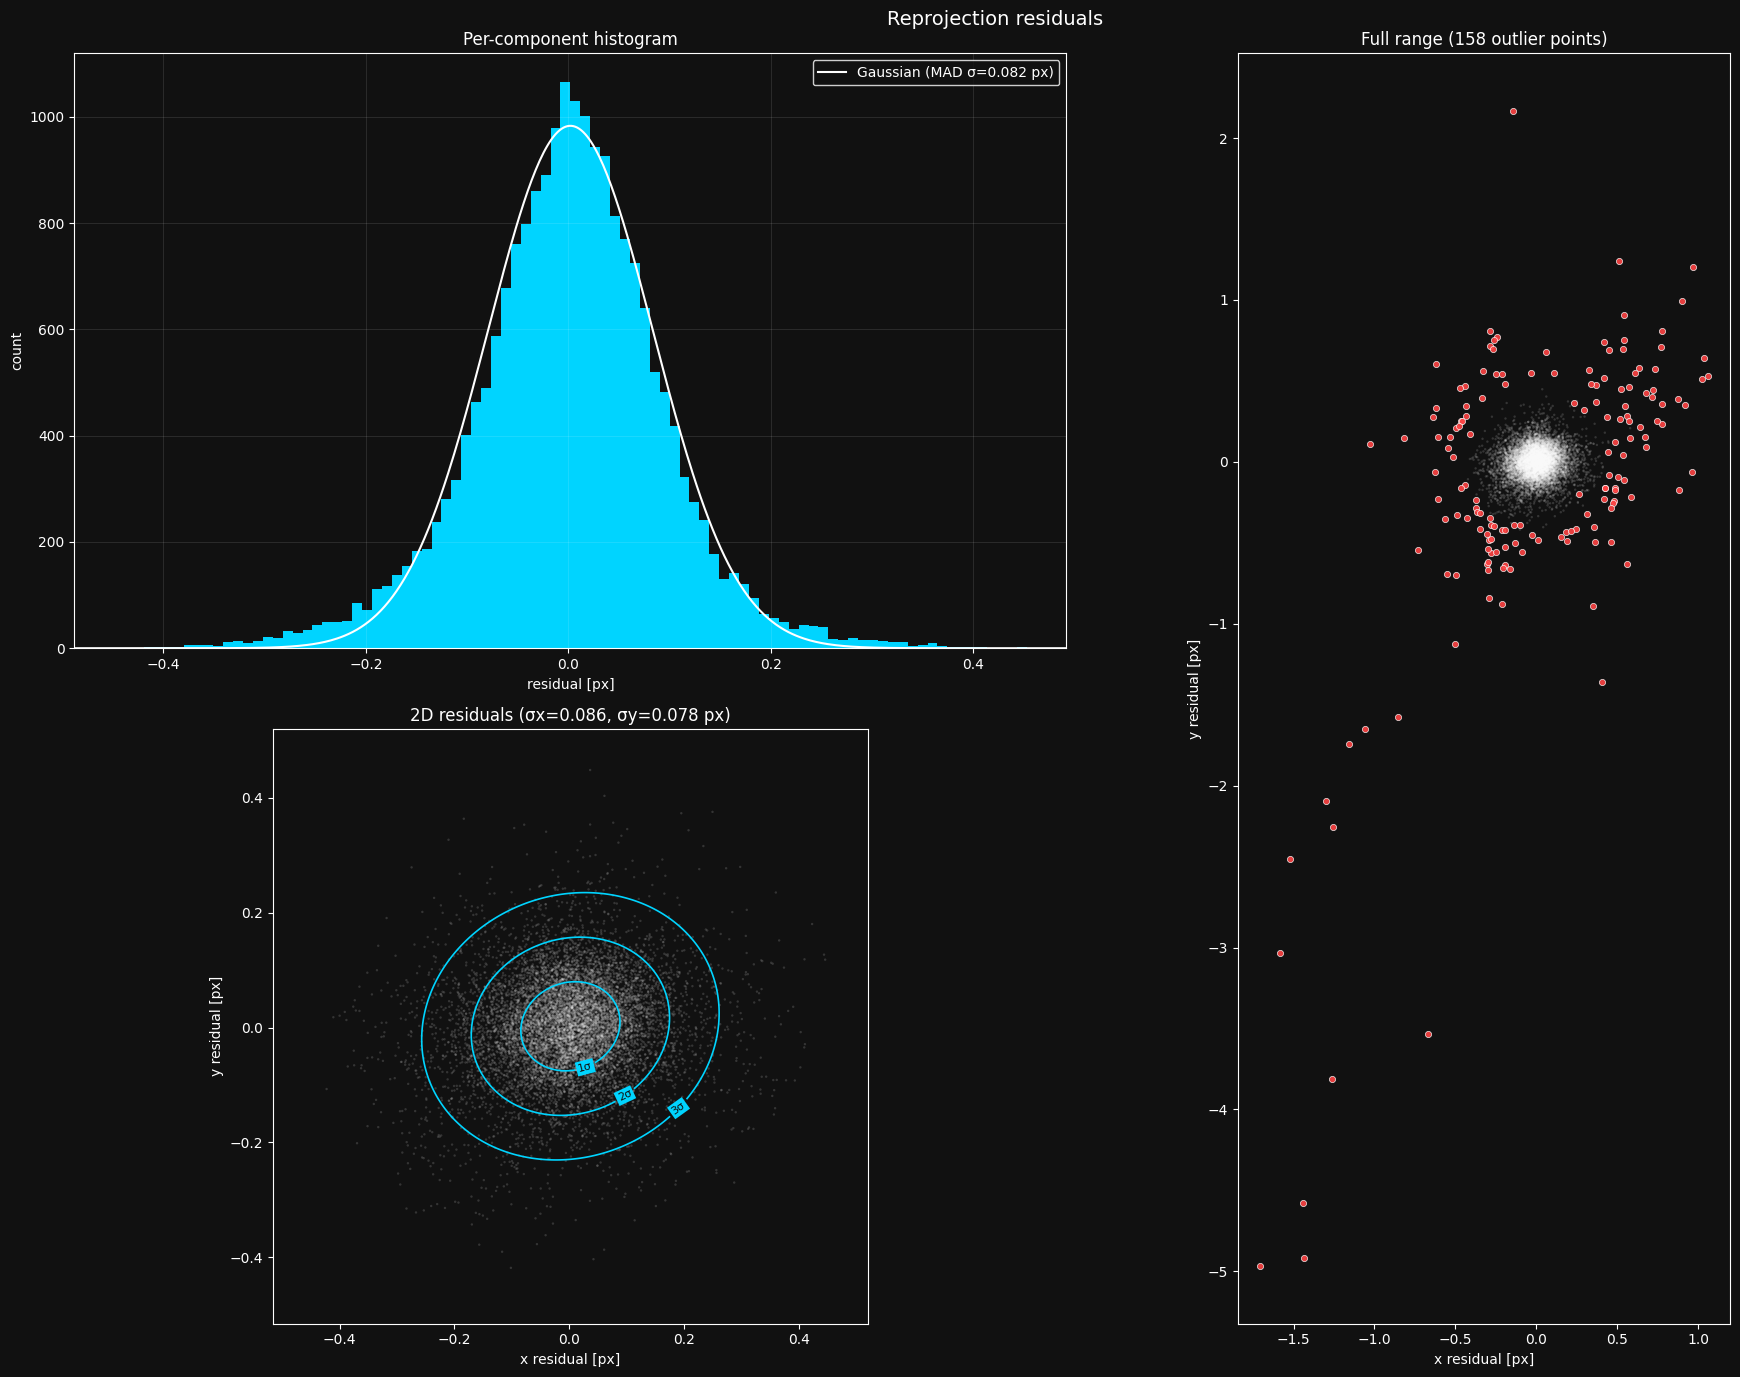

In [10]:
result.plot_residuals()

The residuals look pretty gaussian, and the spread is tight. The 2D residuals look roughly isotropic, which is a good sign.

There are some pretty bad outliers. Let's see the per-image RMS of the residuals to spot where they happen:

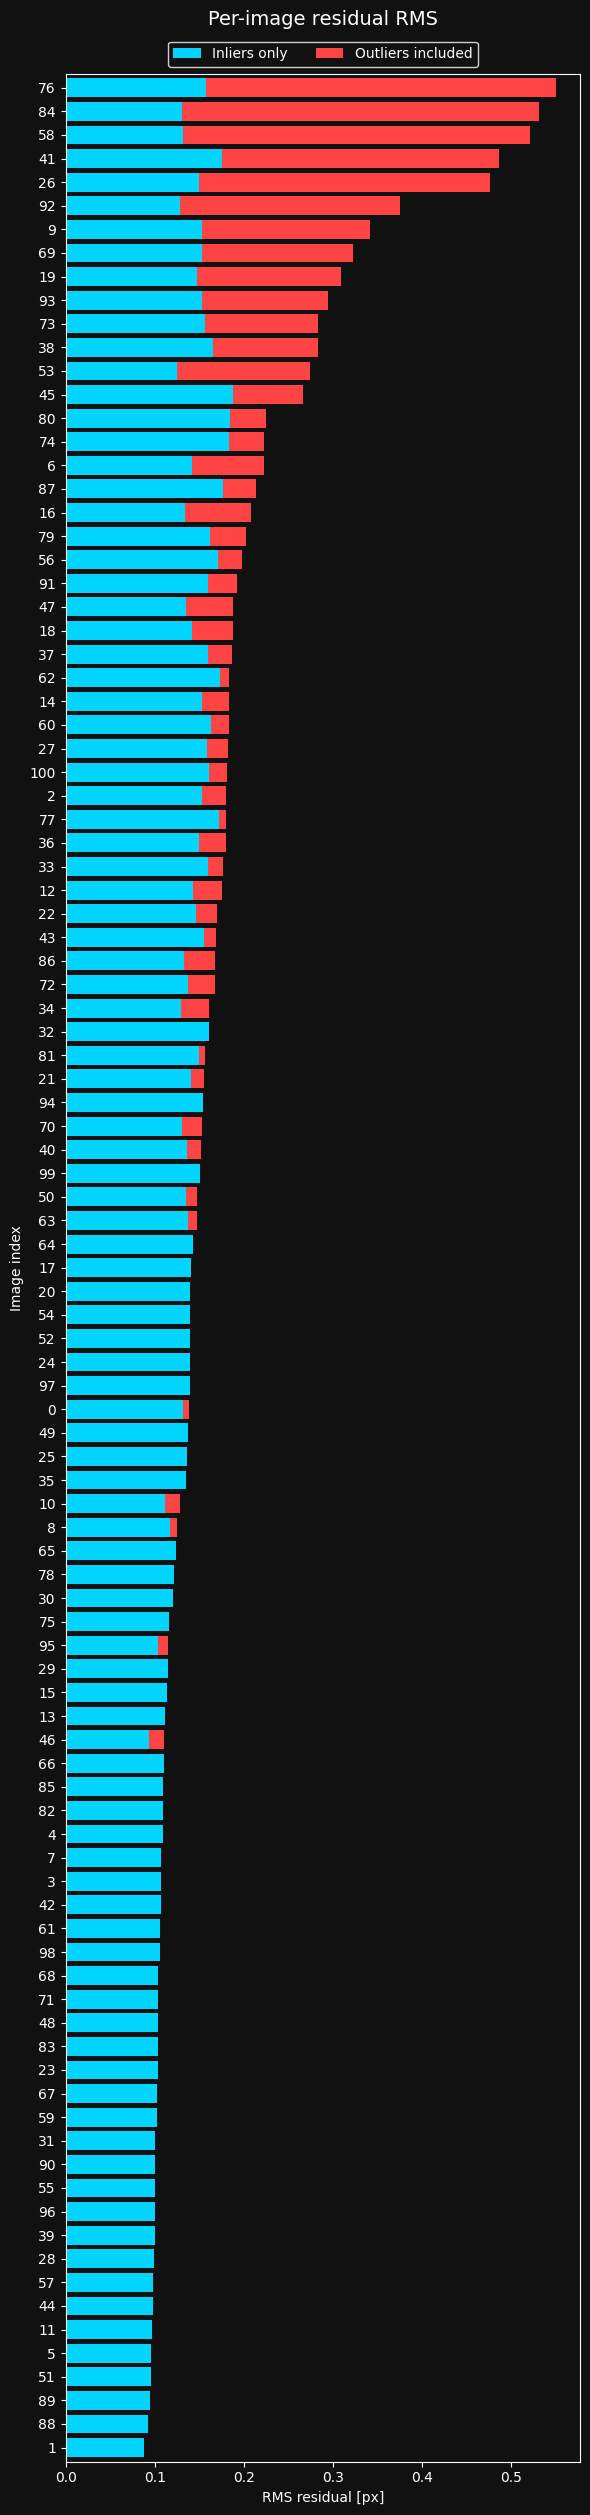

In [11]:
result.plot_per_image_rms()

Seems like some images have some particularly bad detections, but they're all filtered out as outliers. We can take a look at the worst ones:

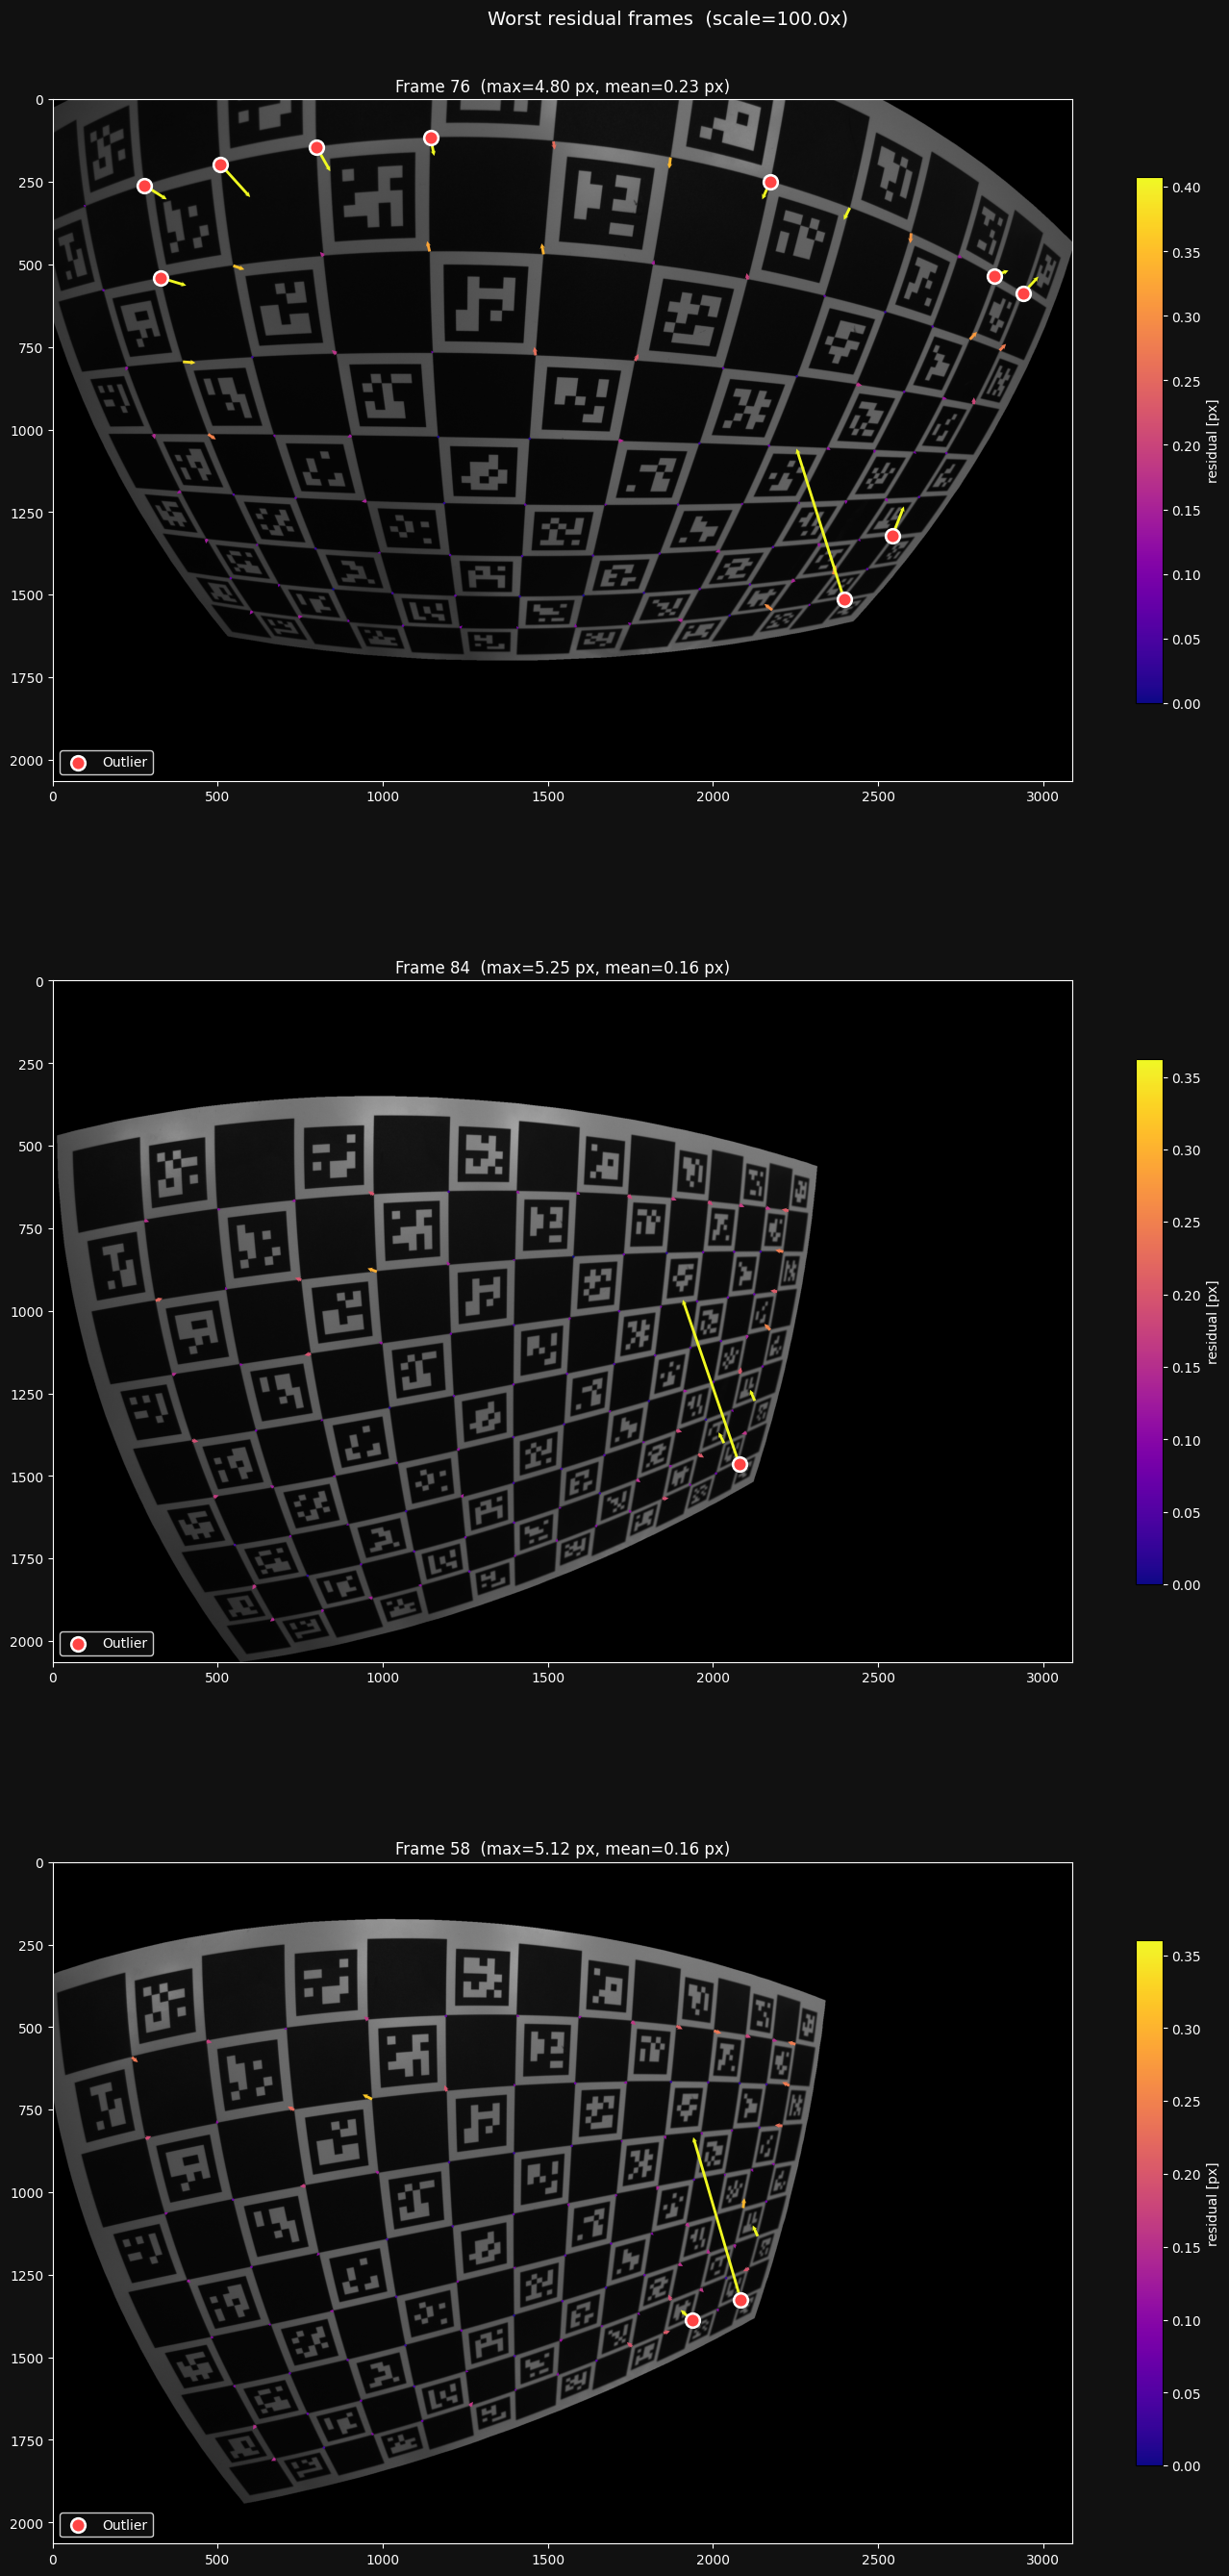

In [12]:
result.plot_worst_residual_frames(used_imgs, n=3)

This looks like some issue with the charuco detector when the board is very distorted - we will not worry about it here, since it's not too frequent, and the errors are filtered out as outliers.

Let's see if we can find any pattern in the residuals. The following plot is useful for this.

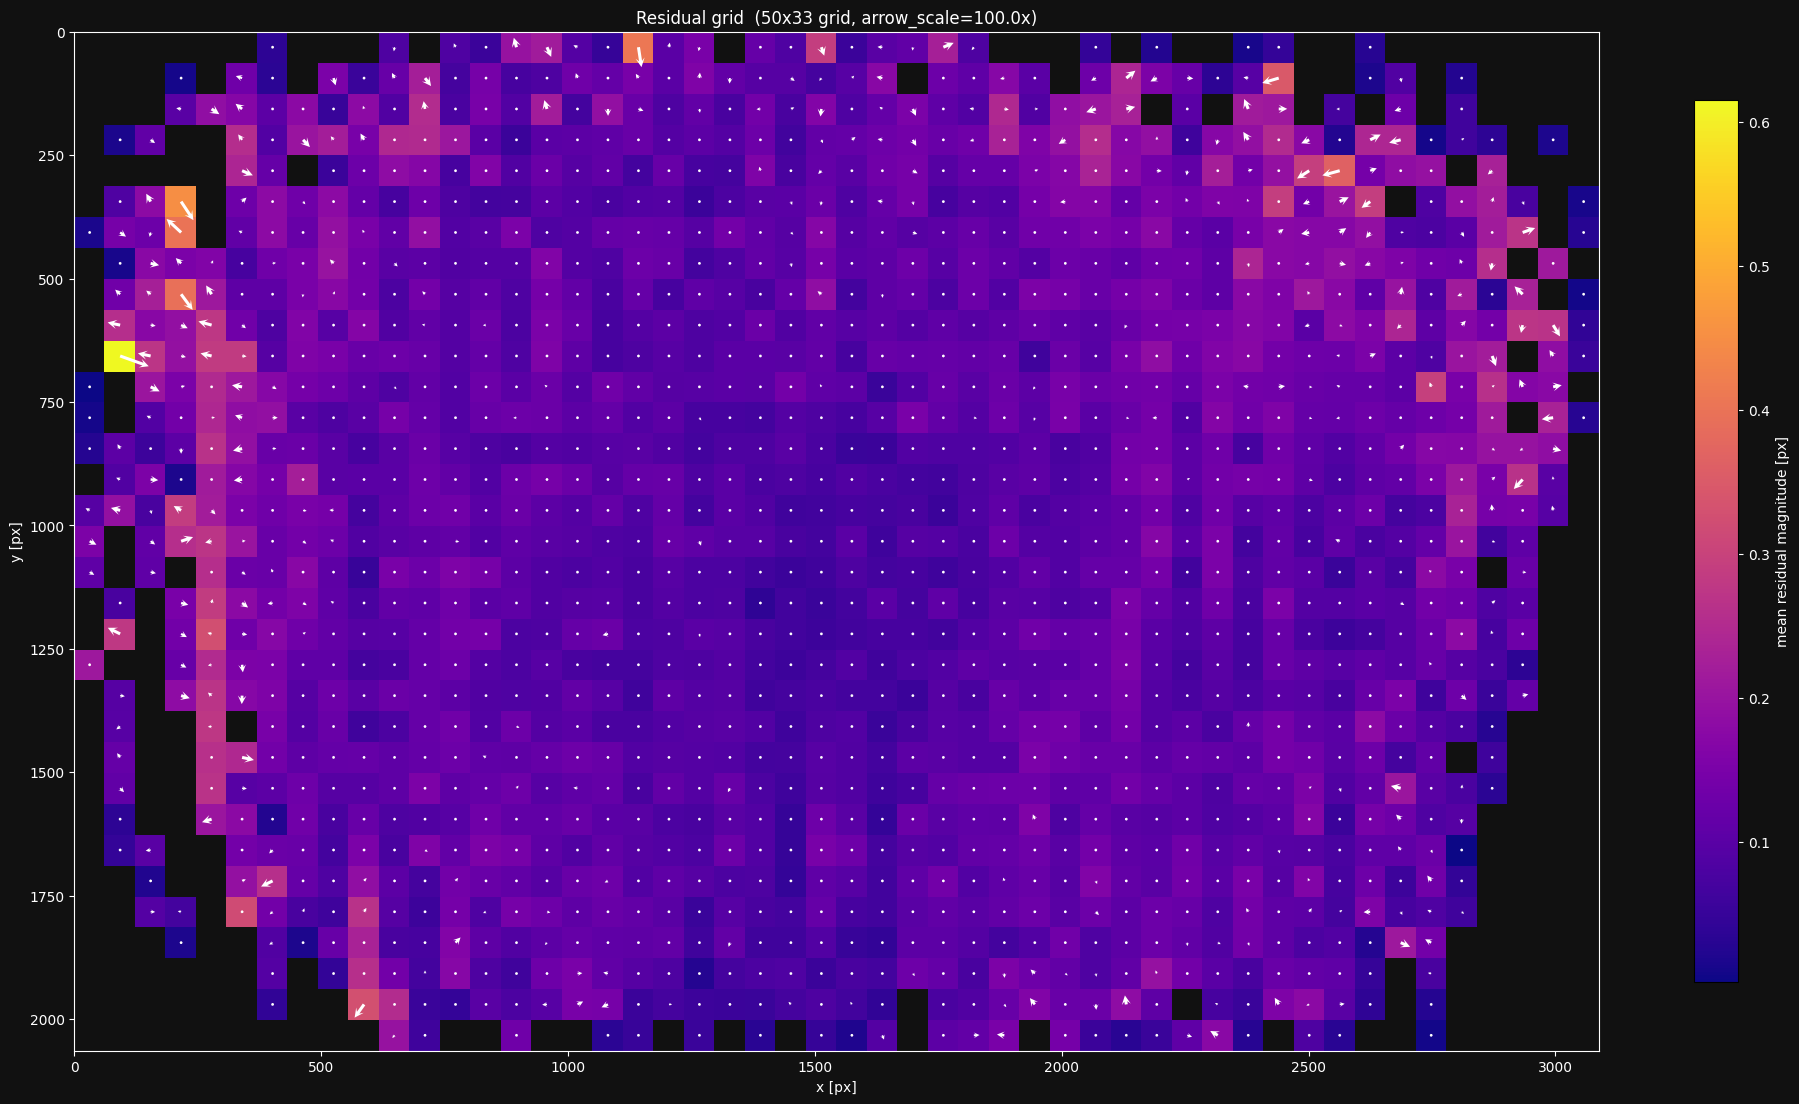

In [13]:
result.plot_residual_grid()

Looks like a great fit with very little systematic error, except at the very edges.

The solver estimated the warp of the calibration target. We can take a look at this warp estimation:

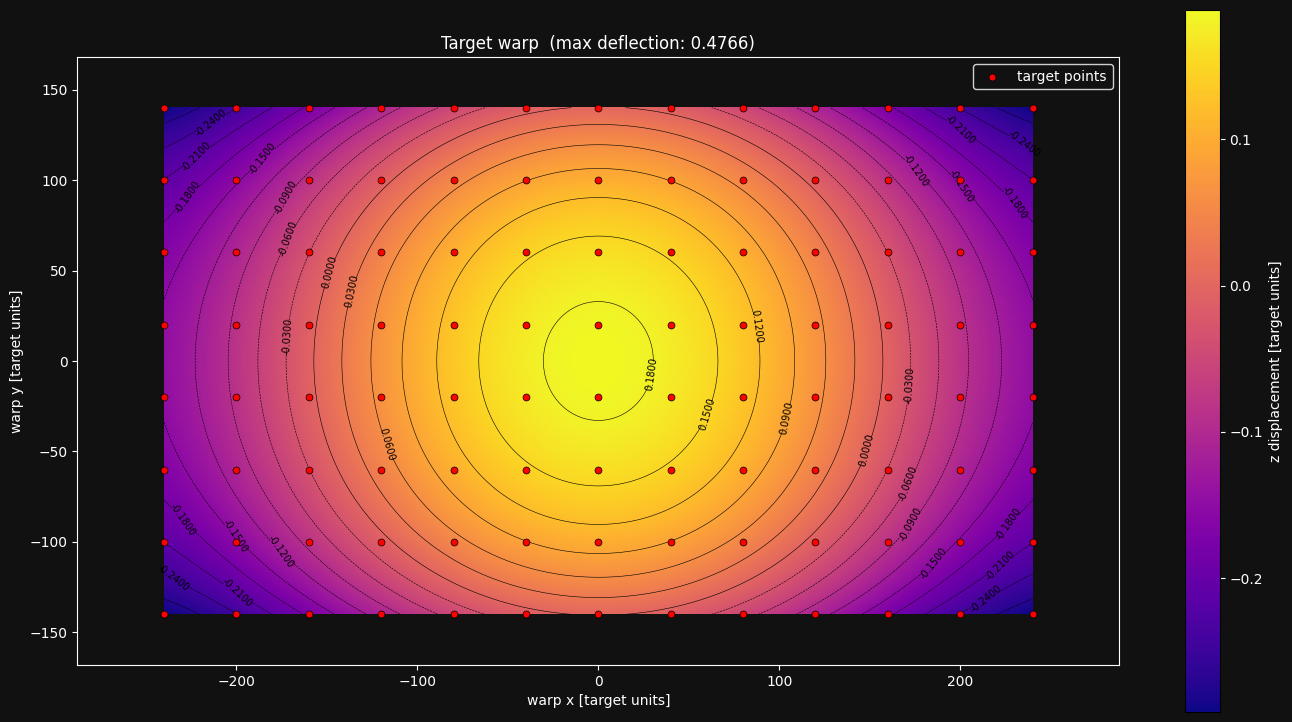

In [14]:
result.plot_target_warp()

The spread of the deflection seems to be about 0.5mm. Not so bad, but solving without the warp gives a noticeably worse fit.

# Undistortion

Since lensboy's spline model is not supported anywhere else, you need to undistort your images before using the camera model for most applications.

We support converting the splined lens model to simple pinhole intrinsics along with undistortion maps:

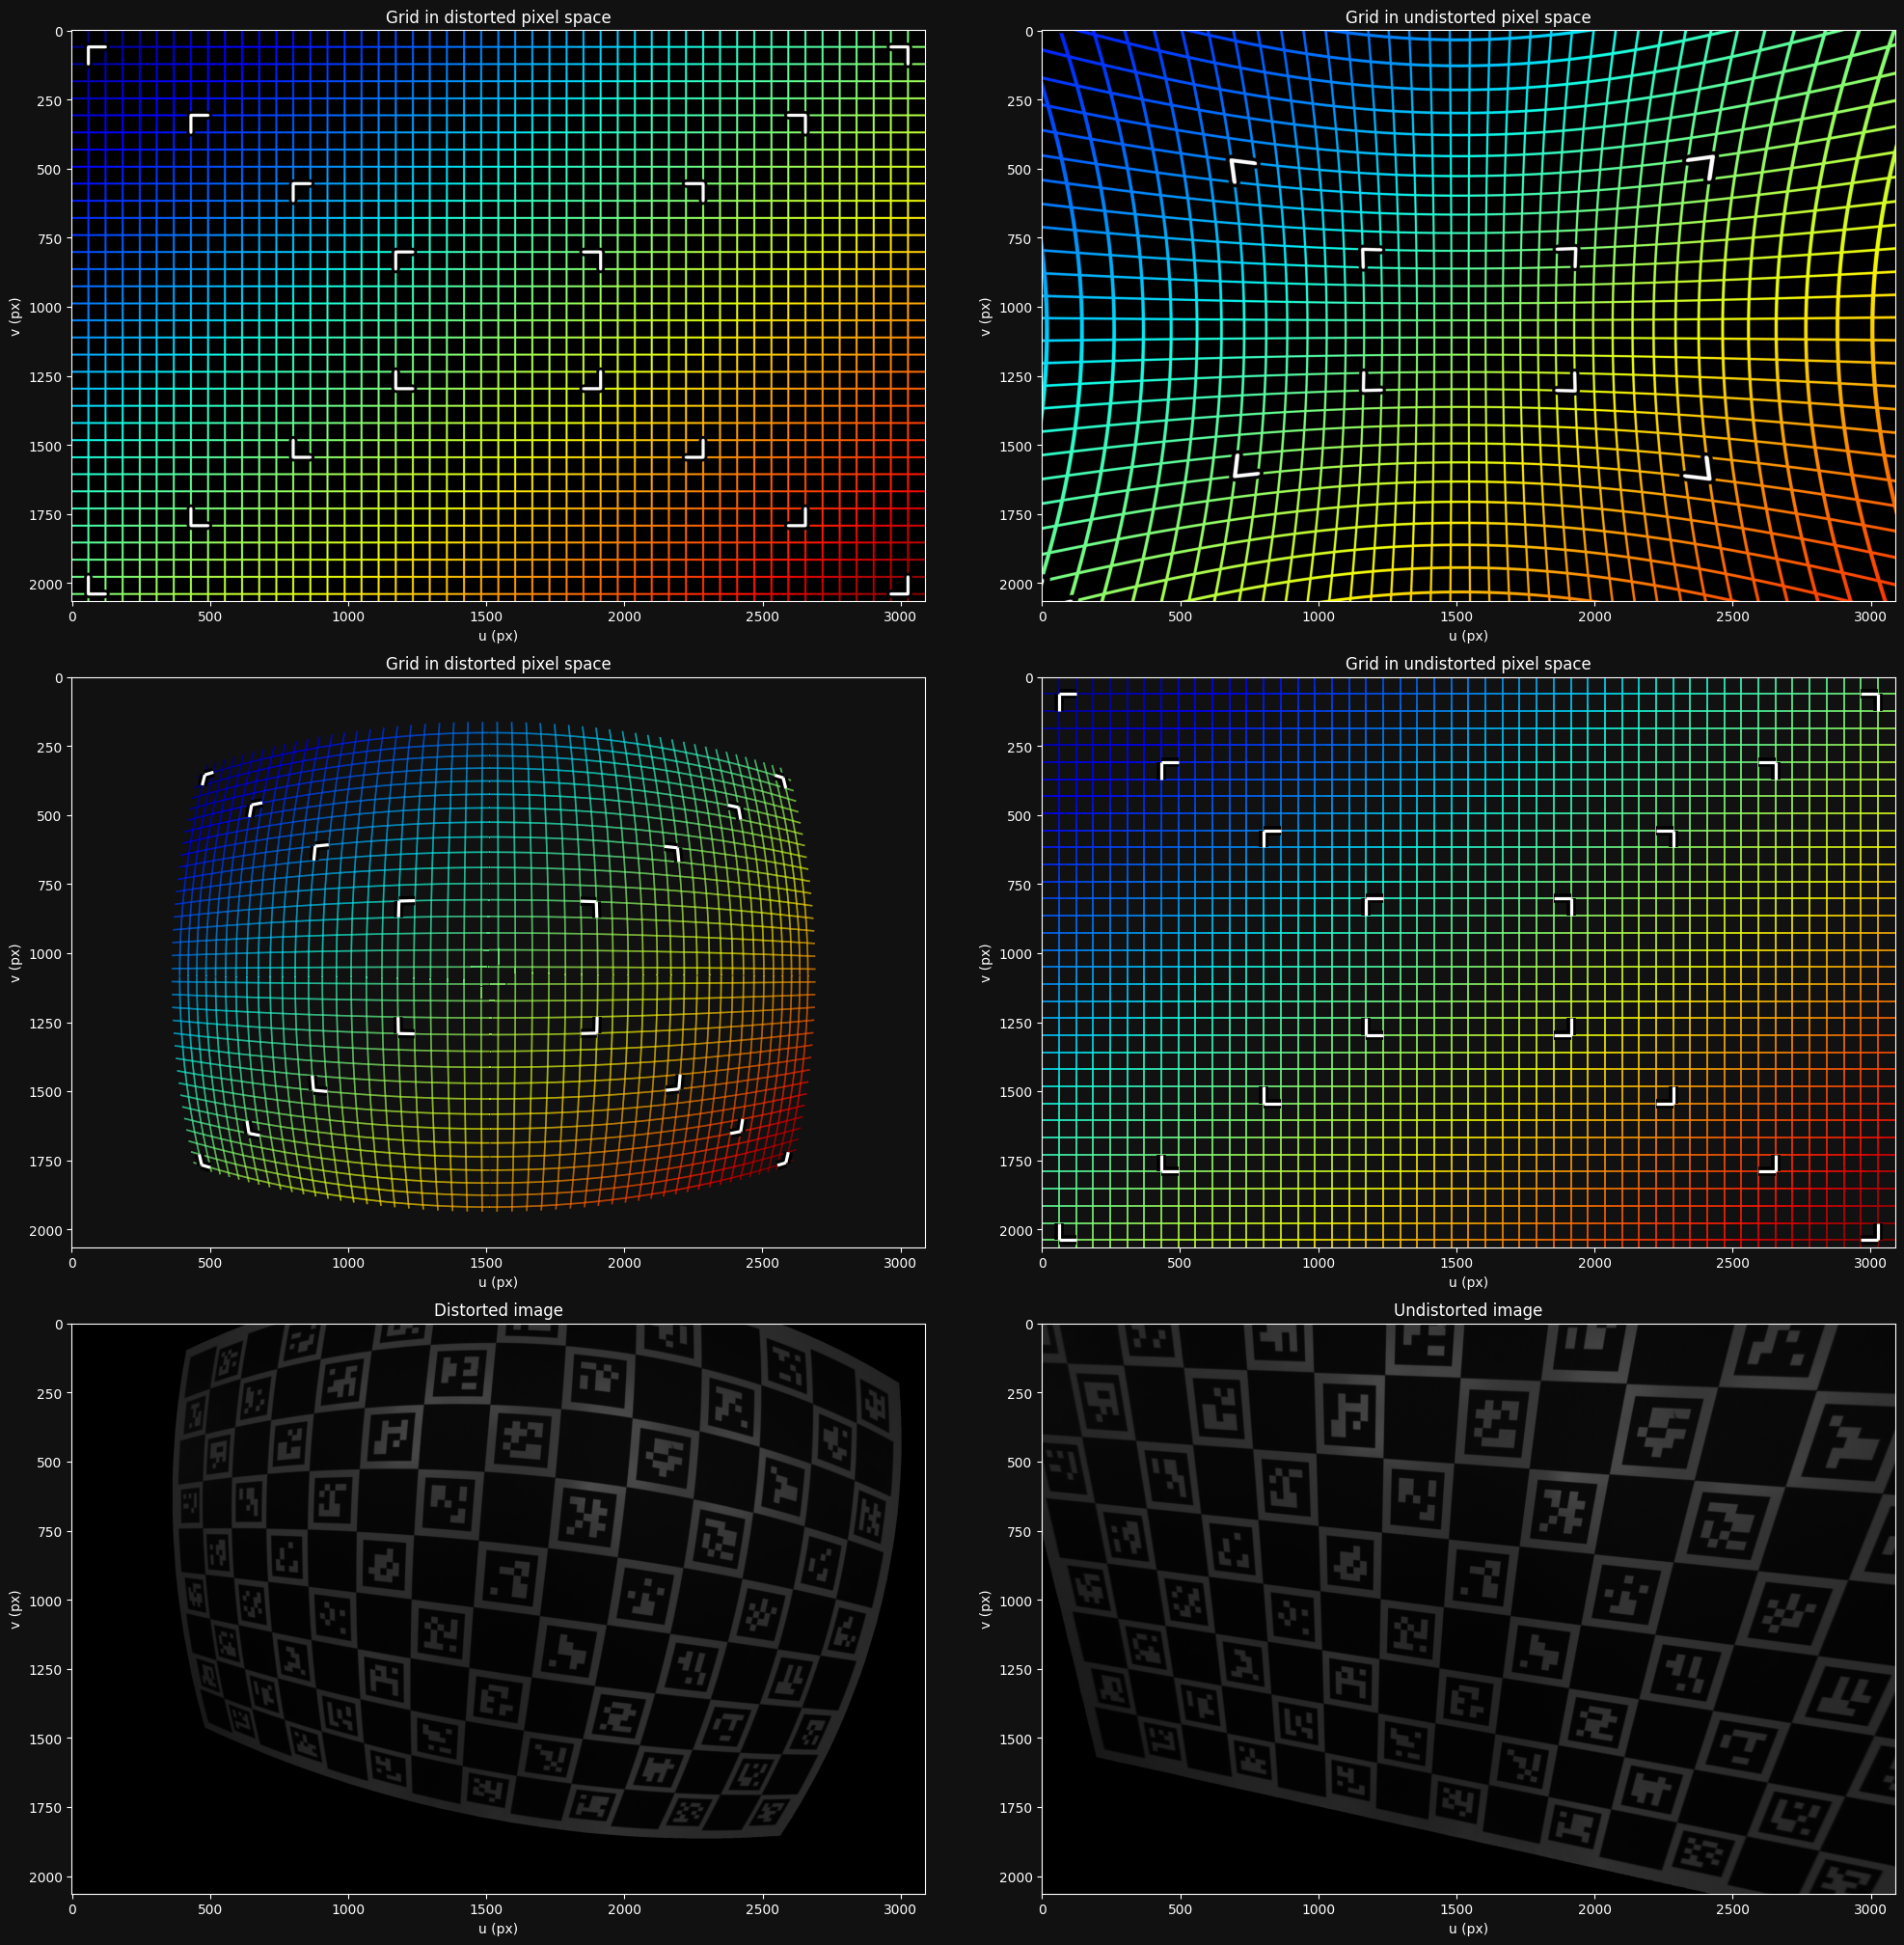

In [15]:
spline_intrinsics = result.camera_model
pinhole_remapped = spline_intrinsics.get_pinhole_model()
lba.plot_undistortion(pinhole_remapped, image=used_imgs[0])

This gives us a good feeling for the undistortion. It's clear we are cutting off a large part of the field of view of the original image here. The reason is that `get_pinhole_model` defaults to using the same focal length and principal point as the spline model.

You can provide custom pinhole parameters and image sizes into `get_pinhole_model`, or use `get_pinhole_model_alpha` which calculates your pinhole parameters based on how much data you are okay with losing.

# Save

When we are happy with our model, we can save it:

In [16]:
model_path = Path("../data/camera_models/spline.json")
result.camera_model.save(model_path)